Information kept:  73.72150366945348 %
Noise variance:  1167.2179532079167
KNN score before PCA:  0.814
KNN score after PCA:  0.856


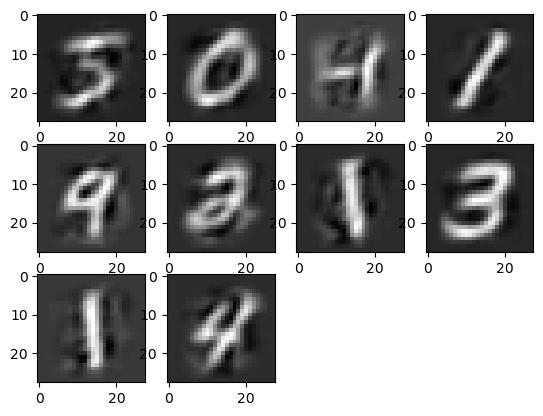

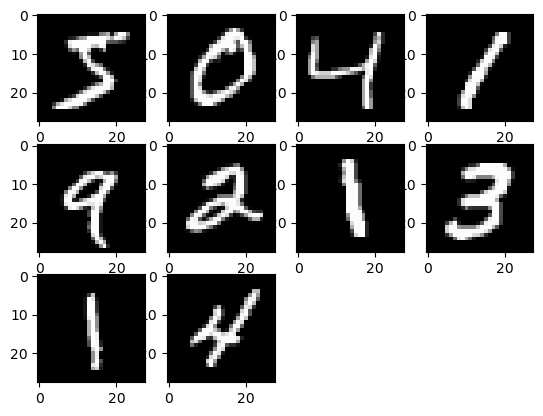

In [1]:
'''
Sample solution for Lab COMP3055 UNNC
Environments:   Python = 3.7.4
                numpy = 1.19.1
                scikit-learn = 0.21.3
                matplotlib = 3.1.1
'''

# ************ Overview ************
# This example demonstrates: 
# (1) how to load the MNIST dataset (with a persistent cache),
# (2) apply PCA for dimensionality reduction, 
# (3) train a simple KNN classifier,
# (4) reconstruct and plot some images to visualize PCA's reconstruction quality.


import os
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST using sklearn.fetch_openml

print('Downloading MNIST dataset using sklearn.fetch_openml()...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# The returned dataset has 70000 rows and 784 columns (28x28 images flattened)
X = mnist['data']  # shape (70000, 784)
y = mnist['target']
# Convert types (y may be string dtype depending on sklearn version)
X = X.astype('uint8')
y = y.astype('int64')

# Split into MNIST standard train/test and reshape back to 28x28
# After this split, x_train/x_test will have shape (-1, 28, 28).
x_train = X[:60000].reshape((-1, 28, 28))
y_train = y[:60000]
x_test = X[60000:].reshape((-1, 28, 28))
y_test = y[60000:]
# Save a compressed local cache for subsequent convenience (not used for skipping download)
MNIST_FILE = 'mnist.npz'
np.savez_compressed(MNIST_FILE, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
data = np.load(MNIST_FILE, allow_pickle=True)

# ************ Prepare train/test arrays for experiments ************
# After loading, we extract the arrays and continue with the lab workflow.
x_train, y_train, x_test, y_test = data['x_train'], data['y_train'], data['x_test'], data['y_test']

# ************ Subsample & reshape for fast experimentation ************
# For speed during the lab we only use the first 1000 train / 1000 test samples.
# Flatten images to 1D vectors of length 784 to feed into PCA and KNN.
X_small = np.reshape(x_train[0:1000], (1000,784))
Y_small = y_train[0:1000]
X_test = np.reshape(x_test[0:1000], (1000,784))
Y_test = y_test[0:1000]

############ Problem I: PCA for dimensionality reduction
# ************ PCA setup & transformation ************
# PCA reduces the 784-pixel feature vector to `n_components` principal components.
# This makes training cheaper and can also reduce noise in the input features.
from sklearn.decomposition import PCA
pca = PCA(n_components=28) # try different n_components for comparison
X_small_trans = pca.fit_transform(X_small)
X_test_trans = pca.transform(X_test)
print('Information kept: ', sum(pca.explained_variance_ratio_)*100, '%')
print('Noise variance: ', pca.noise_variance_)
# The explained_variance_ratio_ provides the proportion of variance retained
# by the selected principal components; the noise_variance_ is sklearn's estimate
# of the variance lost as 'noise' (components removed).

############ Compare classifier performance before & after PCA
# ************ Training KNN and scoring ************
# We use a small k=3 nearest neighbours classifier to make it easy to see
# how dimensionality reduction affects generalization.
from sklearn.neighbors import KNeighborsClassifier
knn0 = KNeighborsClassifier(n_neighbors=3)  # Baseline KNN on raw pixels
knn0.fit(X_small, Y_small)
print('KNN score before PCA: ', knn0.score(X_test, Y_test))

knn1 = KNeighborsClassifier(n_neighbors=3)  # KNN on PCA-reduced features
knn1.fit(X_small_trans, Y_small)
print('KNN score after PCA: ', knn1.score(X_test_trans, Y_test))

############ Problem II: Reconstruction & Visualization
# ************ Visualize reconstructed images and originals ************
# Use the inverse transform of PCA to reconstruct the images from the reduced
# representation. Comparing reconstructed images with the originals helps
# students understand which details are lost when reducing dimensions.
import matplotlib.pyplot as plt

# apply reconstruction and visualize
X_small_trains_reconst = pca.inverse_transform(X_small_trans)

plt.figure()
for i in range(10):
    plt.subplot(3,4,i+1)
    plt.imshow(np.reshape(X_small_trains_reconst[i],(28,28)), cmap=plt.cm.gray)
plt.savefig("X_reconstruct.png")
plt.show()

plt.figure()
for i in range(10):
    plt.subplot(3,4,i+1)
    plt.imshow(np.reshape(X_small[i],(28,28)), cmap=plt.cm.gray)
plt.savefig("X_origin.png")
plt.show()